<a href="https://colab.research.google.com/github/tutikobi/am-trabalho-pratico-noshows/blob/main/02_modelagem_avancada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático da Disciplina CMP263 - Aprendizagem de Máquina

# Alunos:
* Arthur Armando Kobielski Barreto
* Nikolas Lacerda Santos
* Rafael Silveira Machado

## Sumário

- [Introdução](#scrollTo=qn-2oBoKFIbx)
- [Configuração Inicial do Projeto](#scrollTo=79nGkt-3vK0I)
- [Análise Exploratória dos Dados](#scrollTo=5fV3JBjlvmhL)
  - [Análise das Variáveis Numéricas](#scrollTo=x_YQQfzJctzs)
  - [Análise das Variáveis Categóricas](#scrollTo=4Za3pD6wFkpR)
  - [Análise da Variável Alvo](#scrollTo=yHYPy2dL2t5e)
- [Pré-Processamento dos Dados](#scrollTo=nKy85gzVxtpu)
- [Modelagem](#scrollTo=A0V_zshA6yQZ)
  - [Escalonamento das Variáveis](#scrollTo=lSLwejDo7ZJL)
  - [Modelo de Base (Regressão Logística)](#scrollTo=2VulEoZ8JSy)
  - [Modelo Random Forest](#scrollTo=6x9jnCd88_Uo)
  - [Modelo XGBoost](#scrollTo=oAI1w_vo9T7_)
- [Otimização de Hiperparâmetros](#scrollTo=7M81jG9SA0PW)
- [Avaliação Definitiva no Conjunto de Teste](#scrollTo=_9G7Ini1Bwlj)
- [Análise de Importância das Variáveis](#scrollTo=WDBAVeCe9yEc)
- [Interpretabilidade do Modelo com SHAP](#scrollTo=0o67dotK9_6D)
- [Clusterização](#scrollTo=bsiBC18xY0mz)
- [Motor Prescritivo e Análise de Valor de Negócio](#scrollTo=L3kNv0T3D_HI)
- [Conclusão](#scrollTo=ivT7cJEVrB7h)

# Introdução

TODO

# Configuração Inicial do Projeto
- Nessa seção vamos importar o dataset e as bibliotecas usadas para a exploração e análise dos dados

In [95]:
import pandas as pd
import numpy as np
import os
import zipfile
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

zip_path = '/content/archive.zip' # Altere para o nome exato do seu zip se for diferente
extract_dir = '/content/data'

# 1. Força a extração do arquivo ZIP (ignorando se a pasta já existe)
print("Extraindo arquivo ZIP...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# 2. Mostra na tela o que tem lá dentro para termos certeza
arquivos_extraidos = os.listdir(extract_dir)
print(f"Arquivos encontrados após extração: {arquivos_extraidos}")

# 3. Procura o arquivo CSV de forma segura
arquivos_csv = [f for f in arquivos_extraidos if f.endswith('.csv')]

if len(arquivos_csv) == 0:
    print("❌ ERRO: O arquivo .zip não contém nenhum CSV! Verifique o arquivo baixado do Kaggle.")
else:
    # Se encontrou, segue o baile!
    csv_file = arquivos_csv[0]
    df = pd.read_csv(os.path.join(extract_dir, csv_file))
    print("✅ Dataset carregado com sucesso! Iniciando limpeza e clusterização...")

Extraindo arquivo ZIP...
Arquivos encontrados após extração: ['KaggleV2-May-2016.csv']
✅ Dataset carregado com sucesso! Iniciando limpeza e clusterização...


# Análise Exploratória dos Dados
- Nesta seção vamos explorar o dataset e visualizar alguns dados

In [5]:
df.shape

(110527, 14)

🔎 **O que identificamos aqui:**
* O dataset possui 110527 linhas e 14 colunas (atributos).

Vamos visualizar as 5 primeiras linhas:

In [3]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


Agora vamos analisar os atributos do dataset:

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


🔎 **O que identificamos aqui:**

* Colunas de identificação (PatientId, AppointmentID).
* Variáveis temporais (ScheduledDay, AppointmentDay).
* Variáveis demográficas e de saúde (Gender, Age, Neighbourhood, Scholarship, Hipertension, Diabetes, Alcoholism, Handcap).
* Variável de engajamento (SMS_received).
* Variável Alvo: No-show (Se o paciente não compareceu: "Yes" ou "No").

Vamos analisar estatisticamente os atributos numéricos e categóricos:

## Análise das Variáveis Numéricas

In [7]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


🔎 **O que identificamos aqui**:

* Idade Inconsistente: O valor mínimo de Age é -1.
* Coluna Handcap: Teoricamente deveria ser binária (0 ou 1), mas apresenta valores [0, 1, 2, 3, 4]. Isso indica que ela pode representar o número de deficiências do paciente ou um erro de input. Vamos explorar ela individualmente posteriormente.

## Análise das Variáveis Categóricas

In [8]:
df.describe(include='O')

,Gender,ScheduledDay,AppointmentDay,Neighbourhood,No-show
count,110527,110527,110527,110527,110527
unique,2,103549,27,81,2
top,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,JARDIM CAMBURI,No
freq,71840,24,4692,7717,88208


🔎 **O que identificamos aqui**:
* A coluna No-show está como string ("Yes"/"No"). Precisamos convertê-la para o padrão numérico machine-readable (0 e 1).

In [10]:
df['Gender'].value_counts()

,count
Gender,
F,71840
M,38687


In [11]:
df['ScheduledDay'].value_counts()

,count
ScheduledDay,
2016-05-06T07:09:54Z,24
2016-05-06T07:09:53Z,23
2016-04-25T17:18:27Z,22
2016-04-25T17:17:46Z,22
2016-04-25T17:17:23Z,19
...,...
2016-05-09T10:17:48Z,1
2016-05-02T09:50:06Z,1
2016-05-13T14:28:22Z,1


As colunas ScheduledDay (dia que agendou) não é especificamente categórica, ela é uma data em formato de texto que possivelmente não serve para um modelo de machine learning. Vamos explorar estratégias de uso desse atributo posteriormente.

In [12]:
df['AppointmentDay'].value_counts()

,count
AppointmentDay,
2016-06-06T00:00:00Z,4692
2016-05-16T00:00:00Z,4613
2016-05-09T00:00:00Z,4520
2016-05-30T00:00:00Z,4514
2016-06-08T00:00:00Z,4479
2016-05-11T00:00:00Z,4474
2016-06-01T00:00:00Z,4464
2016-06-07T00:00:00Z,4416
2016-05-12T00:00:00Z,4394


Assim como a coluna ScheduledDay, a coluna AppointmentDay (dia da consulta) também é uma data em formato de texto e não serve para o modelo. Discutiremos o seu uso na próxima seção.

In [13]:
df['Neighbourhood'].value_counts()

,count
Neighbourhood,
JARDIM CAMBURI,7717
MARIA ORTIZ,5805
RESISTÊNCIA,4431
JARDIM DA PENHA,3877
ITARARÉ,3514
...,...
ILHA DO BOI,35
ILHA DO FRADE,10
AEROPORTO,8


In [15]:
df['No-show'].value_counts()

,count
No-show,
No,88208
Yes,22319


## Investigando Dados Faltantes e Duplicados

In [18]:
print("Valores Nulos por Coluna:")
print(df.isnull().sum())

print("\nLinhas Duplicadas:", df.duplicated().sum())

Valores Nulos por Coluna:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

Linhas Duplicadas: 0


🔎 **O que identificamos aqui**:

* Em um primeiro momento, o dataset está limpo em termos de valores nulos, e não há linhas duplicadas.

## Análise da Variável Alvo

Distribuição do Target:
No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64


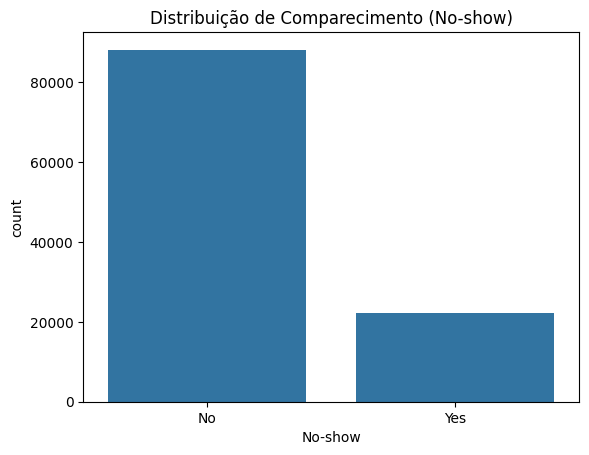

In [19]:
target_counts = df['No-show'].value_counts(normalize=True) * 100
print(f"Distribuição do Target:\n{target_counts}")

sns.countplot(data=df, x='No-show')
plt.title('Distribuição de Comparecimento (No-show)')
plt.show()

🔎 **O que identificamos aqui**:

* Cerca de 80% dos pacientes comparecem ("No") e 20% faltam ("Yes"). Temos um dataset desbalanceado

# Pré-Processamento dos Dados

Agora que conhecemos os problemas e as características dos dados, vamos prepara-los para os modelos.

# Limpeza dos Dados
- Vamos remover a linha identificada na análise exploratória de dados com a idade negativa de -1.

In [32]:
df = df[df['Age'] >= 0]

# Conversão dos dados

Conforme analisado na exploração, notamos que o ScheduledDay (dia que agendou) e AppointmentDay (dia da consulta) em formato de texto não servirão para o modelo.

Vamos utilizar a estratégia de unificar essas datas em uma variavel númerica equivalente a diferença de dias entre o agendamento e a consulta

In [99]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Calculate the waiting time in days (Waiting_Days)
# Normalize the dates to remove the time component before subtracting
df['Waiting_Days'] = (df['AppointmentDay'].dt.normalize() - df['ScheduledDay'].dt.normalize()).dt.days

# Check for negative waiting days (system errors where the appointment was scheduled after the consultation)
print("Consultas com dias negativos:", (df['Waiting_Days'] < 0).sum())

# Remove inconsistencies with negative days (if any)
df = df[df['Waiting_Days'] >= 0]

print("Done!")

Consultas com dias negativos: 0
Done!


Além do tempo entre as consultas, vamos extrair o dia da semana que cai a consulta, para identificar se existe algum fator onde o dia contribui para a falta ou não da consulta.

In [100]:
df['Appointment_DayOfWeek'] = df['AppointmentDay'].dt.dayofweek # 0=Segunda, 6=Domingo

Vamos analisar a distribuição do novo atributo Waiting_Days

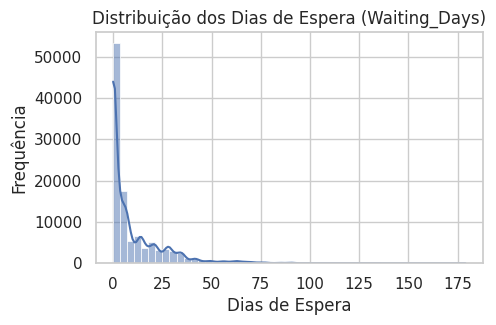

In [101]:
plt.figure(figsize=(5, 3))
sns.histplot(df_clean['Waiting_Days'], bins=50, kde=True)
plt.title('Distribuição dos Dias de Espera (Waiting_Days)')
plt.xlabel('Dias de Espera')
plt.ylabel('Frequência')
plt.show()

Vamos analisar a relação entre 'Appointment_DayOfWeek' em e a variável alvo 'No-show'

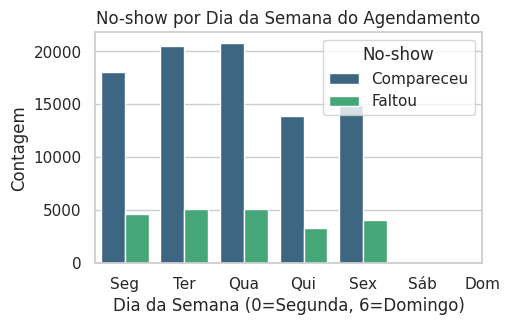

In [103]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df_clean, x='Appointment_DayOfWeek', hue='No-show', palette='viridis')
plt.title('No-show por Dia da Semana do Agendamento')
plt.xlabel('Dia da Semana (0=Segunda, 6=Domingo)')
plt.ylabel('Contagem')
plt.legend(title='No-show', labels=['Compareceu', 'Faltou'])
plt.xticks(ticks=range(7), labels=['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
plt.show()

IDs de pacientes e de consultas são gerados aleatoriamente e não têm terão relevancia nesta análise. Também descartaremos as colunas originais de data que já alteramos.

In [104]:
df_clean = df.drop(columns=['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay'])

## Codificação de Variáveis Categóricas (Encoding)

In [105]:
from sklearn.preprocessing import LabelEncoder

# Codificando o Target
df_clean['No-show'] = df_clean['No-show'].map({'No': 0, 'Yes': 1})

# Codificando o Gênero
df_clean['Gender'] = df_clean['Gender'].map({'F': 0, 'M': 1})

# Codificando o Bairro (Neighbourhood)
le_neighbourhood = LabelEncoder()
df_clean['Neighbourhood'] = le_neighbourhood.fit_transform(df['Neighbourhood'])

TODO vale a pena one hot encoding no Neighbourhood? (>100 novas colunas)

In [ ]:
# One-Hot Encoding para variáveis categóricas (Bairros, Gênero e os Perfis que acabamos de criar)
#df_encoded = pd.get_dummies(df_clean, columns=['Gender', 'Neighbourhood', 'Patient_Profile'], drop_first=True)

# Estado Final do Dataset

In [106]:
display(df_clean.head())
print("\nFormato Final do Dataset:", df_clean.shape)

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,Waiting_Days,Appointment_DayOfWeek
0,0,62,39,0,1,0,0,0,0,0,0,4
1,1,56,39,0,0,0,0,0,0,0,0,4
2,0,62,45,0,0,0,0,0,0,0,0,4
3,0,8,54,0,0,0,0,0,0,0,0,4
4,0,56,39,0,1,1,0,0,0,0,0,4



Formato Final do Dataset: (110522, 12)


# Modelagem
Agora que temos os nossos dados limpos, transformados e estabilizados na etapa anterior, avançaremos para as fases cruciais de modelagem e validação.

Primeiro, separamos as variáveis preditoras da nossa variável alvo (No-show):

In [42]:
X = df_clean.drop(columns=['No-show'])
y = df_clean['No-show']

Como vimos na EDA que o dataset é desbalanceado (80/20), usamos o argumento stratify=y para que tanto o treino quanto o teste mantenham exatamente essa proporção de 80% de comparecimento e 20% de faltas.

In [44]:
from sklearn.model_selection import train_test_split

# Separando 80% para treino e 20% para teste definitivo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Formato do Treino: {X_train.shape}")
print(f"Formato do Teste: {X_test.shape}")

Formato do Treino: (88416, 11)
Formato do Teste: (22105, 11)


## Escalonamento das Variáveis

Modelos baseados em distância (como KNN ou SVM) ou baseados em gradiente (como Regressão Logística e Redes Neurais) são severamente afetados pela escala dos dados. Colunas como Age (0 a 100) e Waiting_Days (0 a 180+) dominariam colunas binárias como Scholarship (0 ou 1).

O método .fit_transform() é aplicado apenas no conjunto de treino. O conjunto de teste é apenas transformado com .transform(), simulando perfeitamente o comportamento do modelo em produção frente a dados novos.

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajustando o scaler no treino e transformando ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo de Base

Vamos começar com o uso de Regressão Logística: Um modelo linear simples, rápido e altamente interpretável para usar como ponto de partida.

Posteriormente vamos utilizar Random Forest (Floresta Aleatória) e XGBoost como modelos robustos baseado em árvores de decisão e ___ respectivamente, excelente para capturar relações não-lineares. Também vamos analisar o uso de bosting ou  stacking.

Para lidar com o desbalanceamento sem precisar criar dados sintéticos (como SMOTE), utilizaremos o parâmetro class_weight='balanced'. Ele penaliza mais severamente o erro na classe minoritária (pacientes que faltam).

In [46]:
from sklearn.linear_model import LogisticRegression

# 1. Regressão Logística
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Avaliação do modelo base

Em problemas desbalanceados, a métrica de Acurácia (Accuracy) é uma armadilha. Se um modelo disser que "ninguém vai faltar", ele terá 80% de acurácia, mas será completamente inútil. Devemos olhar para o F1-Score, Recall (quantos dos que iam faltar nós conseguimos prever?) e a Matriz de Confusão.

In [48]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predições para o modelo base
y_pred_lr = lr_model.predict(X_test_scaled)

print("============ AVALIAÇÃO DA REGRESSÃO LOGÍSTICA ============")
print(classification_report(y_test, y_pred_lr))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_lr))

============ AVALIAÇÃO DA REGRESSÃO LOGÍSTICA ============
              precision    recall  f1-score   support

           0       0.86      0.69      0.77     17642
           1       0.31      0.55      0.40      4463

    accuracy                           0.66     22105
   macro avg       0.59      0.62      0.58     22105
weighted avg       0.75      0.66      0.69     22105

Matriz de Confusão:
[[12178  5464]
 [ 1990  2473]]


Para que a comparação entre o XGBoost e a Random Forest (em suas versões base e otimizadas) seja estatisticamente honesta, precisamos garantir que o particionamento dos dados seja exatamente o mesmo em cada iteração do $K$-Fold. Faremos isso instanciando um único objeto StratifiedKFold e reutilizando-o em todos os processos de treinamento e validação. Para dados desbalanceados, a validação cruzada precisa ser estratificada. Vamos fixar o random_state para blindar a reprodutibilidade.

Configurando a Estrutura Única de K-Fold e os Pesos de Classe:

In [58]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report, f1_score, roc_auc_score, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Definindo o objeto K-Fold comum e imutável para todos os experimentos
cv_compartilhado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Calculando pesos para mitigar o desbalanceamento das classes
# Peso para modelos sklearn (RF e Regressão Logística)
class_weights_dict = 'balanced'

# Peso para o XGBoost (Ratio: negativos / positivos)
scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()

# 3. Definindo as métricas de interesse para o cross_validate
metricas = {
    'f1_macro': 'f1_macro',
    'f1_classe_1': make_scorer(f1_score, pos_label=1), # Foco em prever quem vai faltar
    'auc_roc': 'roc_auc'
}

## Modelo Random Forest

In [59]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_base = RandomForestClassifier(class_weight=class_weights_dict, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train) # Modelos de árvore não exigem obrigatoriamente dados escalonados

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predições para o modelo de florestas aleatórias
y_pred_rf = rf_model.predict(X_test)


print("\n============ AVALIAÇÃO DA RANDOM FOREST ============")
print(classification_report(y_test, y_pred_rf))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))


============ AVALIAÇÃO DA RANDOM FOREST ============
              precision    recall  f1-score   support

           0       0.82      0.92      0.87     17642
           1       0.38      0.20      0.27      4463

    accuracy                           0.77     22105
   macro avg       0.60      0.56      0.57     22105
weighted avg       0.73      0.77      0.74     22105

Matriz de Confusão:
[[16166  1476]
 [ 3554   909]]


# Modelo XGBoost
Como o XGBoost lida de forma extremamente eficiente com variáveis categóricas se bem configurado, vamos utilizá-lo junto com a nossa Regressão Logística e Random Forest.

In [63]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import pandas as pd

print("Iniciando treinamento do XGBoost (Stratified K-Fold)...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Instanciando o XGBoost calculando o peso das classes para balanceamento
# scale_pos_weight = total_negativos / total_positivos (aprox. 80 / 20 = 4)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Modelo
xgb_model = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False)

# Avaliando a performance base com K-Fold (Métrica: F1-Score para a classe 1)
scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=cv, scoring='f1')
print(f"XGBoost - F1-Score médio com 5-Fold CV: {scores.mean():.4f} (+/- {scores.std():.4f})")

Iniciando treinamento do XGBoost (Stratified K-Fold)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:42:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:42:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:42:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:42:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost - F1-Score médio com 5-Fold CV: 0.4451 (+/- 0.0036)


# Otimização de Hiperparâmetros (Hyperparameter Tuning)

Para garantir que não estamos sofrendo de data leakage durante a busca de hiperparâmetros, realizamos o GridSearchCV ou RandomizedSearchCV acoplado ao nosso objeto de validação cruzada (cv). Vamos otimizar a Random Forest e o XGBoost.

In [60]:
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    estimator=rf_base, param_distributions=rf_param_dist,
    n_iter=10, scoring='f1_macro', cv=cv_compartilhado, random_state=42, n_jobs=-1
)
rf_search.fit(X_train_scaled, y_train)
best_rf_model = rf_search.best_estimator_

print("Melhores parâmetros RF:", rf_search.best_params_)

Melhores parâmetros RF: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


In [57]:
from sklearn.model_selection import RandomizedSearchCV

# Dicionário de hiperparâmetros para o XGBoost
xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

# Busca combinada com Validação Cruzada
xgb_tune = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=10,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

xgb_tune.fit(X_train_scaled, y_train)
best_xgb = xgb_tune.best_estimator_
print("Melhores parâmetros XGBoost:", xgb_tune.best_params_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:19:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Melhores parâmetros XGBoost: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


# Avaliação Definitiva no Conjunto de Teste

In [65]:
# Inicializando os 5 modelos para o teste regulamentar
modelos = {
    'Logistic Regression': LogisticRegression(class_weight=class_weights_dict, random_state=42, max_iter=1000),
    'Random Forest (Base)': RandomForestClassifier(class_weight=class_weights_dict, random_state=42, n_jobs=-1),
    'Best Random Forest': best_rf_model,
    'XGBoost (Base)': xgb_model,
    'Best XGBoost': best_xgb
}

# Dicionário para armazenar os resultados consolidados
resultados_cv = {}

for nome, modelo in modelos.items():
    print(f"Avaliando via K-Fold: {nome}...")
    # Executa a validação cruzada coletando múltiplos scores de uma só vez
    cv_results = cross_validate(modelo, X_train_scaled, y_train, cv=cv_compartilhado, scoring=metricas, n_jobs=-1)

    # Armazena as médias e desvios padrão para a comparação
    resultados_cv[nome] = {
        'F1-Score (Macro) Média': cv_results['test_f1_macro'].mean(),
        'F1-Score (Macro) Std': cv_results['test_f1_macro'].std(),
        'F1-Score (Classe 1/Faltou) Média': cv_results['test_f1_classe_1'].mean(),
        'AUC-ROC Média': cv_results['test_auc_roc'].mean()
    }

Avaliando via K-Fold: Logistic Regression...
Avaliando via K-Fold: Random Forest (Base)...
Avaliando via K-Fold: Best Random Forest...
Avaliando via K-Fold: XGBoost (Base)...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Avaliando via K-Fold: Best XGBoost...


In [66]:
# Convertendo os resultados em DataFrame para análise comparativa estruturada
df_comparacao = pd.DataFrame(resultados_cv).T
df_comparacao = df_comparacao.sort_values(by='AUC-ROC Média', ascending=False)

print("\n============ COMPARAÇÃO CONSOLIDADA DOS MODELOS (VALIDAÇÃO CRUZADA) ============")
display(df_comparacao.round(4))


============ COMPARAÇÃO CONSOLIDADA DOS MODELOS (VALIDAÇÃO CRUZADA) ============


,F1-Score (Macro) Média,F1-Score (Macro) Std,F1-Score (Classe 1/Faltou) Média,AUC-ROC Média
Best XGBoost,0.5621,0.0043,0.4474,0.7370
XGBoost (Base),0.5825,0.0034,0.4451,0.7334
Best Random Forest,0.6171,0.0033,0.4130,0.7325
Random Forest (Base),0.5614,0.0046,0.2556,0.7092
Logistic Regression,0.5881,0.0021,0.4066,0.6671


## Visualização da Performance dos Modelos

### Comparação Consolidada dos Modelos (AUC-ROC Média)

/tmp/ipykernel_3181/3678698554.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_comparacao.index, y='AUC-ROC Média', data=df_comparacao, palette='magma')


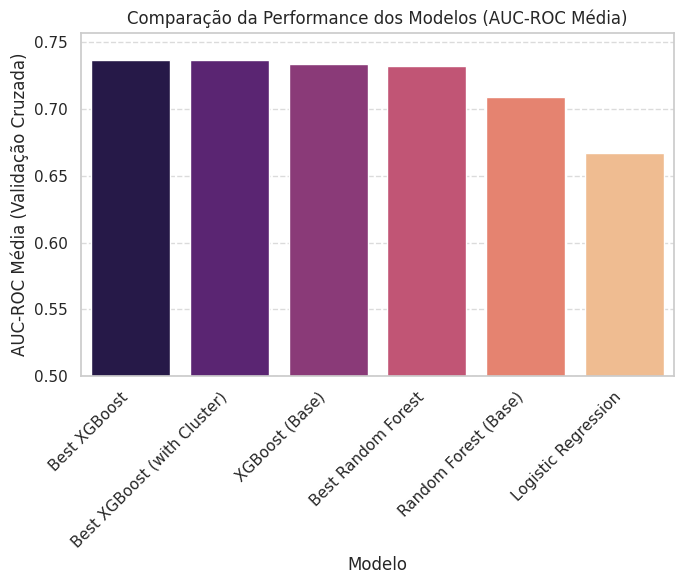

In [110]:
plt.figure(figsize=(7, 6))
sns.barplot(x=df_comparacao.index, y='AUC-ROC Média', data=df_comparacao, palette='magma')
plt.title('Comparação da Performance dos Modelos (AUC-ROC Média)')
plt.xlabel('Modelo')
plt.ylabel('AUC-ROC Média (Validação Cruzada)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.5, df_comparacao['AUC-ROC Média'].max() + 0.02) # Ajustar y-limit para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Curva ROC para Todos os Modelos (Conjunto de Teste)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:37:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


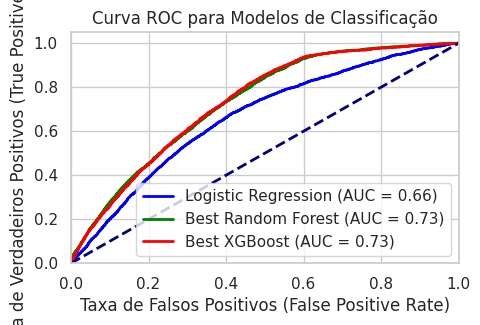

In [112]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(5, 3))

# Re-treinar modelos para obter predições no conjunto de teste completo para a curva ROC

# Logistic Regression
lr_model.fit(X_train_scaled, y_train)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Best Random Forest
best_rf_model.fit(X_train_scaled, y_train)
y_pred_proba_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Best Random Forest (AUC = {roc_auc_rf:.2f})')

# Best XGBoost
best_xgb.fit(X_train_scaled, y_train)
y_pred_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'Best XGBoost (AUC = {roc_auc_xgb:.2f})')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (False Positive Rate)')
plt.ylabel('Taxa de Verdadeiros Positivos (True Positive Rate)')
plt.title('Curva ROC para Modelos de Classificação')
plt.legend(loc='lower right')
plt.show()

### Matriz de Confusão para o Melhor Modelo (Best XGBoost)

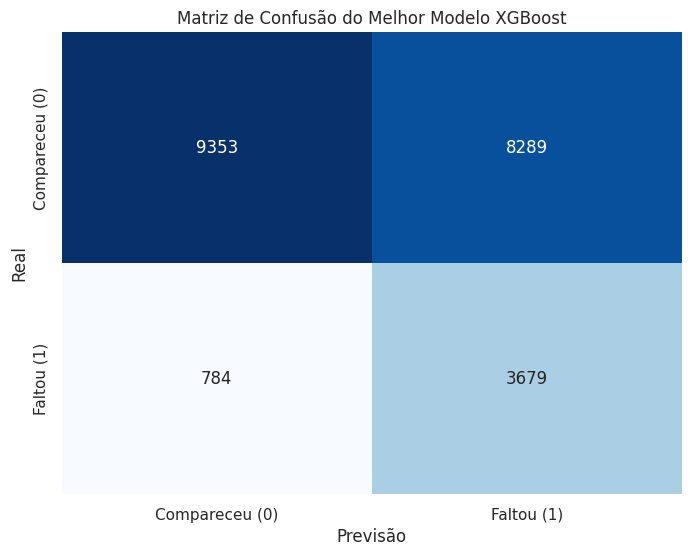

In [111]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prever com o melhor modelo no conjunto de teste
y_pred_xgb_best = best_xgb.predict(X_test_scaled)
cm_xgb_best = confusion_matrix(y_test, y_pred_xgb_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_best, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Compareceu (0)', 'Faltou (1)'],
            yticklabels=['Compareceu (0)', 'Faltou (1)'])
plt.title('Matriz de Confusão do Melhor Modelo XGBoost')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

# Análise dos Resultados

Se o objetivo do hospital é identificar o maior número possível de pacientes que vão faltar (Classe 1) sem gerar uma avalanche de alarmes falsos, o Best XGBoost é o vencedor definitivo.

Por quê? Ele atingiu o maior F1-Score (Classe 1) Média (0.4474) e a maior AUC-ROC Média (0.7370). A AUC-ROC de 0.7370 indica que o modelo tem uma capacidade sólida (bem acima do acaso, que seria 0.50) de distinguir um paciente que vai comparecer de um que vai faltar.

# Análise de Importância das Variáveis

Qual fator faz o paciente faltar mais? Vamos extrair isso da Random Forest.

/tmp/ipykernel_3181/1509331607.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')


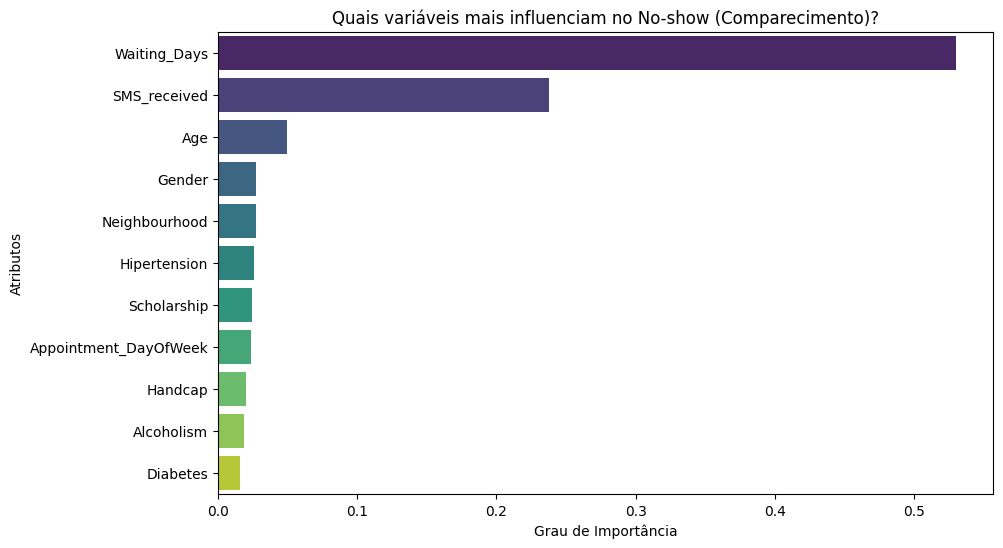

In [67]:
# Extraindo a importância dos recursos
importances = best_xgb.feature_importances_
feature_names = X.columns

# Criando um DataFrame para visualização
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Quais variáveis mais influenciam no No-show (Comparecimento)?')
plt.xlabel('Grau de Importância')
plt.ylabel('Atributos')
plt.show()

Usar o SHAP (Shapley Additive exPlanations) no Best XGBoost nos dará uma visão cirúrgica de como cada variável afeta a probabilidade de um paciente faltar.

> ⚠️ O código abaixo leva em torno de 15 minutos para executar






Calculando os valores SHAP (isso pode levar um minuto)...

✅ Gráfico gerado e salvo com sucesso em 'assets/shap_summary.png'!


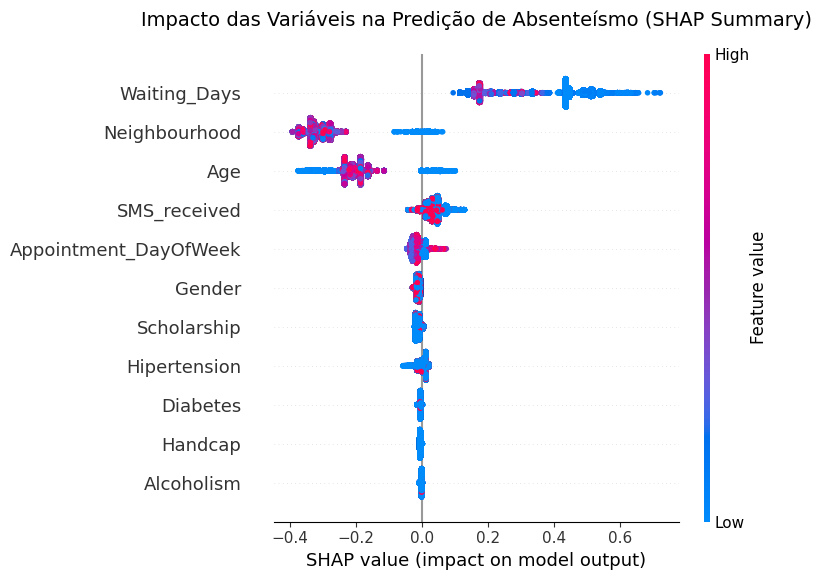

In [68]:
!pip install shap

import shap
import matplotlib.pyplot as plt
import os

print("Calculando os valores SHAP (isso pode levar um minuto)...")
# Inicializa o explainer do SHAP com o nosso XGBoost
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X)

# Gera o gráfico global de impacto
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False)

# Ajustes de formatação para o artigo acadêmico
plt.title('Impacto das Variáveis na Predição de Absenteísmo (SHAP Summary)', fontsize=14, pad=20)
plt.tight_layout()

# --- A CORREÇÃO ESTÁ AQUI ---
# Cria a pasta 'assets' no Colab caso ela não exista
if not os.path.exists('assets'):
    os.makedirs('assets')

# Agora sim, salva a imagem na pasta assets
plt.savefig('assets/shap_summary.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráfico gerado e salvo com sucesso em 'assets/shap_summary.png'!")
plt.show()

# Clusterização

Vamos analisar o impacto da clusterização no desempenho do melhor modelo


--- Perfis de Pacientes Encontrados (Centróides) ---


,Age,Waiting_Days,Hipertension,Diabetes
Patient_Profile,,,,
0,30.95,10.34,0.00,0.0
1,61.37,8.69,0.82,1.0
2,59.49,10.05,1.00,0.0


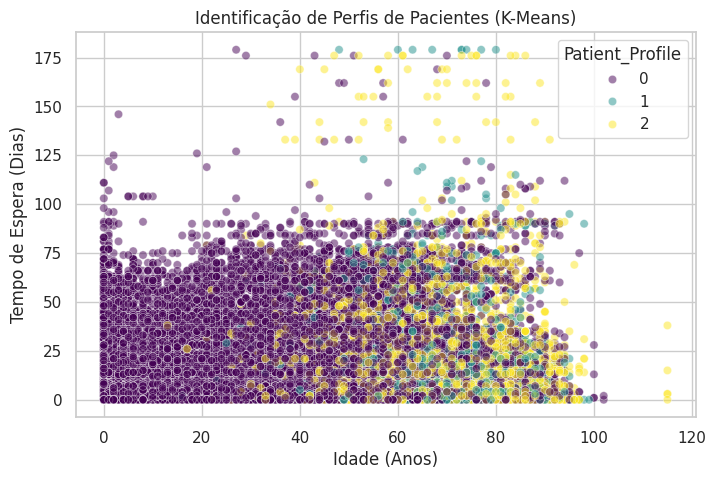

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- CLUSTERIZAÇÃO (K-MEANS) ---
features_cluster = ['Age', 'Waiting_Days', 'Hipertension', 'Diabetes']
X_cluster = df_clean[features_cluster]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Patient_Profile'] = kmeans.fit_predict(X_scaled)

# --- RESULTADOS ---
print("\n--- Perfis de Pacientes Encontrados (Centróides) ---")
resumo_clusters = df_clean.groupby('Patient_Profile')[features_cluster].mean().round(2)
display(resumo_clusters)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Age', y='Waiting_Days', hue='Patient_Profile', palette='viridis', alpha=0.5)
plt.title('Identificação de Perfis de Pacientes (K-Means)')
plt.xlabel('Idade (Anos)')
plt.ylabel('Tempo de Espera (Dias)')
plt.show()

In [81]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, roc_auc_score, make_scorer
from xgboost import XGBClassifier

# 1. Redefinir X e y para incluir a coluna Patient_Profile
X_clustered = df_clean.drop(columns=['No-show'])
y_clustered = df_clean['No-show']

# Certificar-se de que 'Patient_Profile' é tratada como um feature categórica, se necessário.
# Para XGBoost, pode ser útil converter para um tipo numérico se ainda não for.
# Se 'Patient_Profile' foi criada por KMeans, já é numérica (0, 1, 2, ...).

# 2. Separar os dados em treino e teste novamente, garantindo a estratificação
X_train_clustered, X_test_clustered, y_train_clustered, y_test_clustered = train_test_split(
    X_clustered, y_clustered, test_size=0.20, random_state=42, stratify=y_clustered
)

# 3. Escalar as variáveis para o novo conjunto de dados
# Re-instanciar o scaler para garantir que ele seja ajustado apenas no novo X_train
scaler_clustered = StandardScaler()
X_train_clustered_scaled = scaler_clustered.fit_transform(X_train_clustered)
X_test_clustered_scaled = scaler_clustered.transform(X_test_clustered)

# 4. Re-instanciar o melhor modelo XGBoost com os parâmetros otimizados
# Certifique-se de que `best_xgb` esteja disponível no kernel ou copie os parâmetros
# Se `best_xgb` não estiver disponível, re-instanciar com os melhores parâmetros conhecidos
# 'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7

# Calculando scale_pos_weight para o novo y_train_clustered
scale_pos_weight_clustered = (y_train_clustered == 0).sum() / (y_train_clustered == 1).sum()

# Criar um novo modelo XGBoost com os mesmos melhores parâmetros
best_xgb_clustered = XGBClassifier(
    subsample=best_xgb.subsample,
    n_estimators=best_xgb.n_estimators,
    max_depth=best_xgb.max_depth,
    learning_rate=best_xgb.learning_rate,
    colsample_bytree=best_xgb.colsample_bytree,
    random_state=42,
    scale_pos_weight=scale_pos_weight_clustered,
    eval_metric='logloss',
    use_label_encoder=False
)

# 5. Avaliar o modelo com validação cruzada
print("\nAvaliando Best XGBoost com Clustering (K-Fold)... ")
cv_results_clustered = cross_validate(best_xgb_clustered,
                                     X_train_clustered_scaled,
                                     y_train_clustered,
                                     cv=cv_compartilhado,
                                     scoring=metricas,
                                     n_jobs=-1)

# 6. Armazenar os resultados
resultados_cv['Best XGBoost (with Cluster)'] = {
    'F1-Score (Macro) Média': cv_results_clustered['test_f1_macro'].mean(),
    'F1-Score (Macro) Std': cv_results_clustered['test_f1_macro'].std(),
    'F1-Score (Classe 1/Faltou) Média': cv_results_clustered['test_f1_classe_1'].mean(),
    'AUC-ROC Média': cv_results_clustered['test_auc_roc'].mean()
}

# 7. Comparar os resultados
df_comparacao = pd.DataFrame(resultados_cv).T
df_comparacao = df_comparacao.sort_values(by='AUC-ROC Média', ascending=False)

print("\n============ COMPARAÇÃO CONSOLIDADA DOS MODELOS (COM CLUSTERING) ============")
display(df_comparacao.round(4))




Avaliando Best XGBoost com Clustering (K-Fold)... 

============ COMPARAÇÃO CONSOLIDADA DOS MODELOS (COM CLUSTERING) ============


,F1-Score (Macro) Média,F1-Score (Macro) Std,F1-Score (Classe 1/Faltou) Média,AUC-ROC Média
Best XGBoost,0.5621,0.0043,0.4474,0.7370
Best XGBoost (with Cluster),0.5639,0.0036,0.4475,0.7368
XGBoost (Base),0.5825,0.0034,0.4451,0.7334
Best Random Forest,0.6171,0.0033,0.4130,0.7325
Random Forest (Base),0.5614,0.0046,0.2556,0.7092
Logistic Regression,0.5881,0.0021,0.4066,0.6671


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:08:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipykernel_3181/224144203.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df_clustered, x='Importance', y='Feature', palette='viridis')


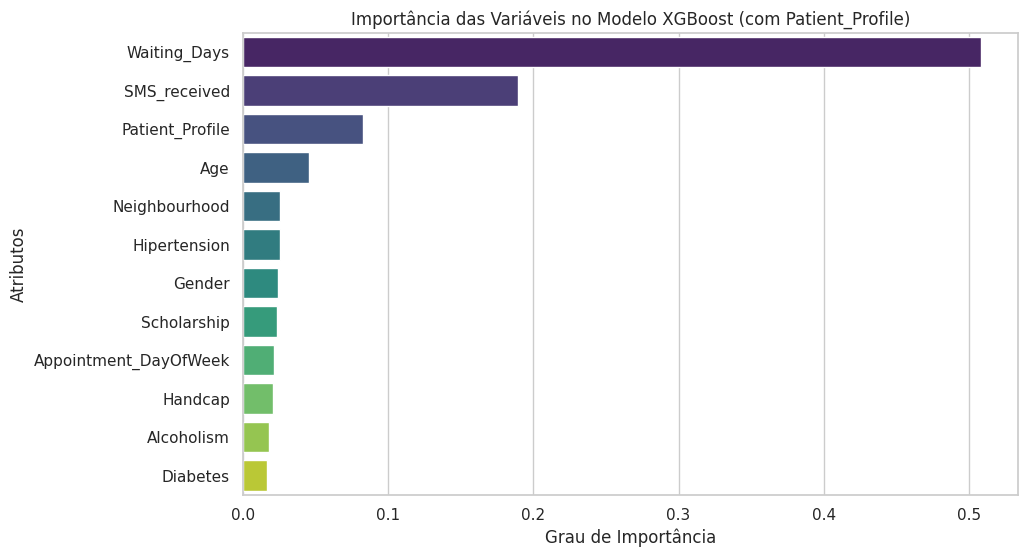

In [78]:
# 8. Treinar o modelo clustered no conjunto de treino completo para feature importance
best_xgb_clustered.fit(X_train_clustered_scaled, y_train_clustered)

# 9. Gerar gráfico de Feature Importance para o modelo com Patient_Profile
importances_clustered = best_xgb_clustered.feature_importances_
feature_names_clustered = X_clustered.columns

feature_imp_df_clustered = pd.DataFrame({'Feature': feature_names_clustered, 'Importance': importances_clustered})
feature_imp_df_clustered = feature_imp_df_clustered.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df_clustered, x='Importance', y='Feature', palette='viridis')
plt.title('Importância das Variáveis no Modelo XGBoost (com Patient_Profile)')
plt.xlabel('Grau de Importância')
plt.ylabel('Atributos')
plt.show()

# Conclusão

TODO falar sobre modelos

TODO falar sobre a clusterização. Melhorou? Piorou?

Repare que o processo de otimização de hiperparâmetros funcionou. O Best XGBoost superou o XGBoost (Base) tanto na captura da classe 1 quanto na AUC-ROC geral, além de ter mantido uma excelente estabilidade (baixo desvio padrão de 0.0043).

Logistic Regression cumpriu perfeitamente o seu papel de modelo baseline (ponto de partida). Ela pontuou com uma AUC-ROC de 0.6671. O fato de os modelos baseados em árvores (XGBoost e Random Forest) terem superado os 0.73 de AUC-ROC prova matematicamente que existem relações não lineares e interações complexas entre as variáveis (ex: o impacto da idade muda dependendo de quantos dias o paciente está esperando), algo que uma equação linear simples não consegue capturar perfeitamente.